In [381]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import umap

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from tqdm import tqdm

from src.data.data import get_ds, get_normalized_ds
from src.visualizations.umap_visualizer import UMAPLatent

In [382]:
class SiameseContrastiveLoss(torch.nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, data, labels):
        batch_size = data.shape[0]
        rangeset = torch.arange(batch_size)
        all_combos = torch.combinations(rangeset)
        same_labels = all_combos[(labels[all_combos[:, 0]] == labels[all_combos[:, 1]]).nonzero()].squeeze()
        opposite_labels = all_combos[(labels[all_combos[:, 0]] != labels[all_combos[:, 1]]).nonzero()].squeeze()
        same_distances = torch.linalg.norm(data[same_labels][:, 0] - data[same_labels][:, 1], dim=1)
        opposite_distances = torch.linalg.norm(data[opposite_labels][:, 0] - data[opposite_labels][:, 1], dim=1)
        same_loss = 0.5*torch.sum(same_distances.pow(2))
        opposite_loss = 0.5*torch.sum(torch.max(torch.tensor(0), self.m - opposite_distances).pow(2))
        final = same_loss + opposite_loss
        return final

In [383]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(2 * hidden_dim, latent_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, (hidden, cell) = self.lstm1(x)
        x = self.dropout(x)
        x, (hidden, cell) = self.lstm2(x)
        return x, hidden[-1, :, :]

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.lstm1 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_dim, output_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        return x

In [384]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, output_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, output_dim)
        
    def forward(self, x):
        x, embeddings = self.encoder(x)
        x = self.decoder(x)
        return x, embeddings

In [385]:
class PrototypeNetwork(nn.Module):
    def __init__(self, latent_dim, num_prototypes, num_classes):
        super(PrototypeNetwork, self).__init__()
        self.prototypes = nn.Parameter(torch.randn(num_prototypes, latent_dim))
        self.classifier = nn.Sequential(
            nn.Linear(num_prototypes, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
            nn.Softmax(dim=1)
        )
        
    def forward(self, x):
        # Calculating distances to prototypes
        x_expanded = x.unsqueeze(1)
        p_expanded = self.prototypes.unsqueeze(0)
        distances = torch.linalg.norm(x_expanded - p_expanded, dim=2)
        
        # Classification
        class_probabilities = self.classifier(distances)
        
        return class_probabilities

In [386]:
class Wrapper(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, output_dim, num_prototypes, num_classes):
        super(Wrapper, self).__init__()
        self.autoencoder = Autoencoder(input_dim, hidden_dim, latent_dim, output_dim)
        self.prototype_network = PrototypeNetwork(latent_dim, num_prototypes, num_classes)
        
    def forward(self, x):
        reconstructions, embeddings = self.autoencoder(x)
        output = self.prototype_network(embeddings)
        
        return reconstructions, output, embeddings


In [387]:
class Trainer:
    def __init__(self, model, train_dataset, test_dataset, variable, index_to_class, batch_size=64, lr=0.0001, epochs=100):
        self.model = model
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.variable = variable
        self.index_to_class = index_to_class

        self.batch_size = batch_size
        self.lr = lr
        self.epochs = epochs
        self.train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.test_dataloader = DataLoader(test_dataset, len(test_dataset), shuffle=False)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.reconstruction_loss_fn = nn.MSELoss()
        self.classification_loss_fn = nn.CrossEntropyLoss()
        
        self.classification_losses = []
        self.reconstruction_losses = []
        self.diversities = []
        self.coverages = []
        self.similarities = []
        self.total_losses = []

    def prototype_diversity_penalty(self):
        prototypes = self.model.prototype_network.prototypes
        num_prototypes, latent_dim = prototypes.shape
        closest_distances = torch.zeros(num_prototypes)
        for i in range(num_prototypes):
            # Slice the tensor to only consider prototypes with higher indices
            remaining_prototypes = prototypes[i+1:, :]
            # Compute Euclidean distances from the current prototype to the remaining prototypes
            distances = torch.linalg.norm(remaining_prototypes - prototypes[i], dim=1)
            # If this is the last prototype, there will be no "remaining_prototypes" so skip
            if distances.nelement() == 0:
                continue
            # Get the minimum distance for this prototype to the remaining ones
            closest_distances[i] = torch.min(distances)
        # Sum the closest distances
        total_distance = torch.sum(closest_distances)
        # Average and take the log
        avg_distance = total_distance / num_prototypes
        log_avg_distance = torch.log(avg_distance)
        # Take the inverse
        diversity = torch.pow(log_avg_distance, -1)
        return diversity
    
    def prototype_similarity_penalty(self, embeddings):
        embeddings_exp = embeddings.unsqueeze(1)
        prototypes_exp = self.model.prototype_network.prototypes.unsqueeze(0)

        distances = torch.linalg.norm(embeddings_exp - prototypes_exp, dim=2)
        min_distances = torch.min(distances, dim=0).values
        sim = torch.sum(min_distances)
        return sim
    
    def encoded_space_coverage_penalty(self, embeddings):
        prototypes = self.model.prototype_network.prototypes

        embeddings_expanded = embeddings.unsqueeze(1)
        prototypes_expanded = prototypes.unsqueeze(0) 

        pairwise_distances = torch.norm(embeddings_expanded - prototypes_expanded, dim=2)
        closest_distances = torch.min(pairwise_distances, dim=1)[0]

        # Sum up all the minimum distances
        total_distance = torch.sum(closest_distances)
        return total_distance
        
    def train(self):
        self.model.train()
        for epoch in tqdm(range(self.epochs)):
            for batch_idx, (data, labels) in enumerate(self.train_dataloader):
                data = data[:, :, self.variable].unsqueeze(2).float()
                self.optimizer.zero_grad()
                reconstructions, pred, embeddings = self.model(data)

                classification_loss = self.classification_loss_fn(pred, labels)
                reconstruction_loss = self.reconstruction_loss_fn(reconstructions, data)
                diversity = self.prototype_diversity_penalty()
                coverage = self.encoded_space_coverage_penalty(embeddings)
                similarity = self.encoded_space_coverage_penalty(embeddings)
                total_loss = (1.0)*classification_loss + \
                             (1.0)*reconstruction_loss + \
                             (1000)*diversity + \
                             (0.0)*coverage + \
                             (0.0)*similarity

                total_loss.backward()
                self.optimizer.step()

            self.classification_losses.append(classification_loss.item())
            self.reconstruction_losses.append(reconstruction_loss.item())
            self.diversities.append(diversity.item())
            self.coverages.append(coverage.item())
            self.similarities.append(similarity.item())
            self.total_losses.append(total_loss.item())
            
    def plot_losses(self):
        plt.figure()
        # plt.plot(self.total_losses, label="Total Loss")
        plt.plot(self.classification_losses, label="Classification Loss")
        plt.plot(self.reconstruction_losses, label="Reconstruction Loss")
        plt.plot(self.diversities, label="Diversity Penalties")
        # plt.plot(self.coverages, label="Encoded Space Coverage")
        # plt.plot(self.similarities, label="Similarity Penalties")
        plt.title('Losses vs Epoch')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    def plot_latent_spaces_with_prototypes(self):
        for data_matrix, labels in self.train_dataloader:
            plt.figure()
            inp = data_matrix[:, :, self.variable].unsqueeze(2).float()
            with torch.no_grad():
                _, _, embeddings = self.model(inp)
                embeddings = torch.concat([embeddings, self.model.prototype_network.prototypes], dim=0)
                out = torch.concat([labels, 4*torch.ones((self.model.prototype_network.prototypes.shape[0],))], dim=0)

                reducer = umap.UMAP()
                embeddings_2d = reducer.fit_transform(embeddings)

                string_labels = np.array([self.index_to_class[float(label)] for label in out])
                unique_labels = ["Standing", "Walking", "Running", "Badminton"]

                handles, lbls = [], []
                for label in unique_labels:
                    idx = np.where(string_labels == label)[0]
                    scatter = plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=label)
                    handles.append(scatter)
                    lbls.append(label)

                idx = np.where(string_labels == "Prototype")[0]
                scatter = plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], marker="*", edgecolor='black', label="Prototype")
                handles.append(scatter)
                lbls.append("Prototype")
                plt.legend(handles, lbls)
                plt.title("Latent Space for Variable " + str(self.variable + 1))
                plt.show()


    def plot_basicmotions_reconstructions(self):
        self.model.eval()
        for data_matrix, labels in self.test_dataloader:
            inp = data_matrix[:, :, self.variable].unsqueeze(2).float()
            with torch.no_grad():
                output, _, _ = self.model(inp)
                print("Blue = original, Red = reconstructed")
                plt.figure()
                index = random.randint(0, 9)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Standing")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(10, 19)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Running")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(20, 29)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]

                plt.title("Walking")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.figure()
                index = random.randint(30, 39)
                p1 = inp[index, :, :].squeeze()
                p2 = output[index, :, :]


                plt.title("Badminton")
                plt.plot(p1, c='b', label="Original")
                plt.plot(p2, c='r', label="Reconstructed")
                plt.legend()

                plt.show()

    def eval(self):
        with torch.no_grad():
            numerator = 0
            denominator = 0
            for data_matrix, label in self.test_dataloader:
                inp = data_matrix[:, :, self.variable].unsqueeze(2).float()
                reconstruction, pred, embeddings = self.model(inp)
                prediction = torch.argmax(pred, 1)

                numerator += torch.sum(prediction.eq(label).int())
                denominator += inp.shape[0]
            accuracy = float(numerator) / float(denominator)
            print("Accuracy: " + str(accuracy))


In [388]:
# Load in BasicMotions dataset
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}
index_to_class = {0:"Standing", 1:"Running", 2:"Walking", 3:"Badminton", 4:"Prototype"}

train_ds, test_ds = get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_normalized_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)

40

In [389]:
model = Wrapper(
    input_dim=1,
    hidden_dim=128,
    latent_dim=32,
    output_dim=1,
    num_prototypes=4,
    num_classes=4
)
trainer = Trainer(
    model=model,
    train_dataset=train_ds,
    test_dataset=test_ds,
    variable=0,
    index_to_class=index_to_class,
    batch_size=40,
    lr=0.0001,
    epochs=1000
)

In [390]:
trainer.train()

100%|██████████| 1000/1000 [02:42<00:00,  6.15it/s]


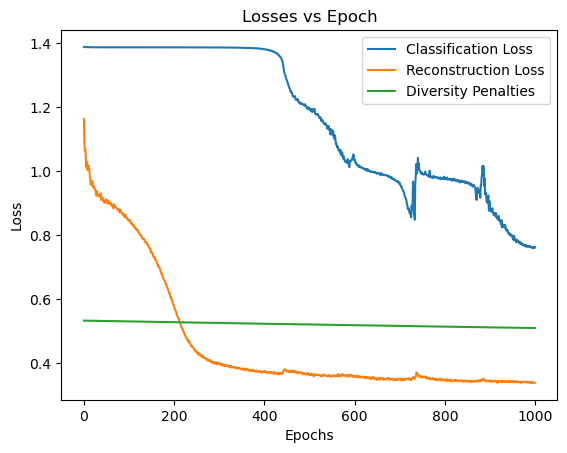

In [391]:
trainer.plot_losses()

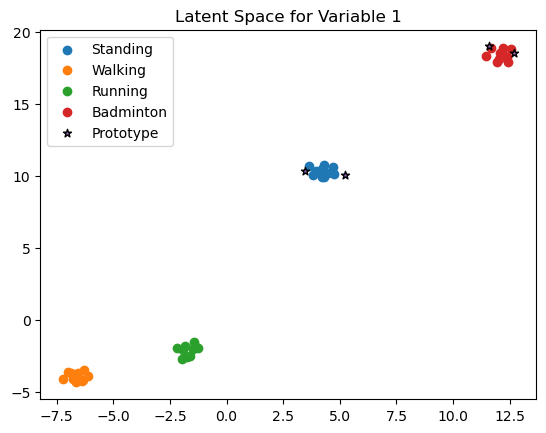

In [392]:
trainer.plot_latent_spaces_with_prototypes()

Blue = original, Red = reconstructed


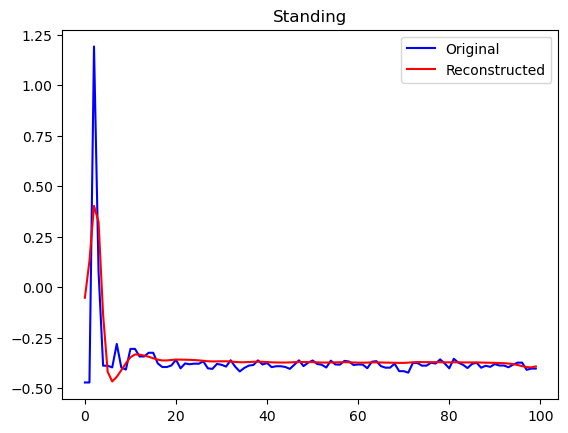

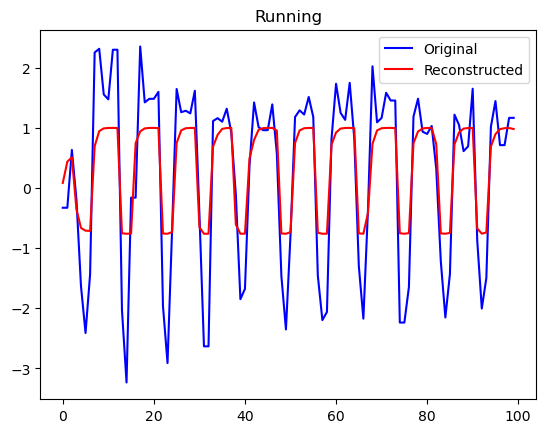

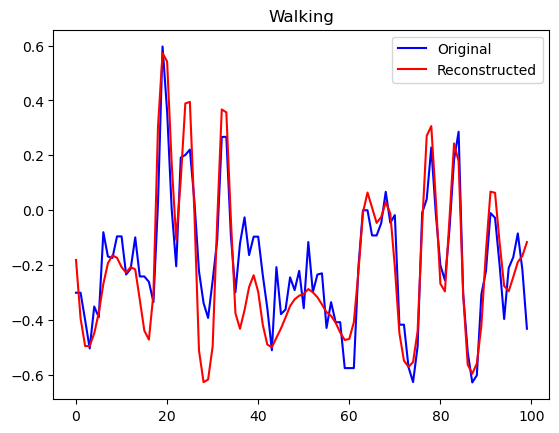

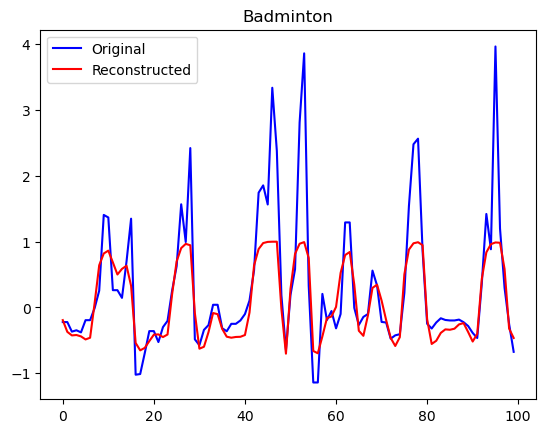

In [393]:
trainer.plot_basicmotions_reconstructions()

In [394]:
trainer.eval()

Accuracy: 0.975
